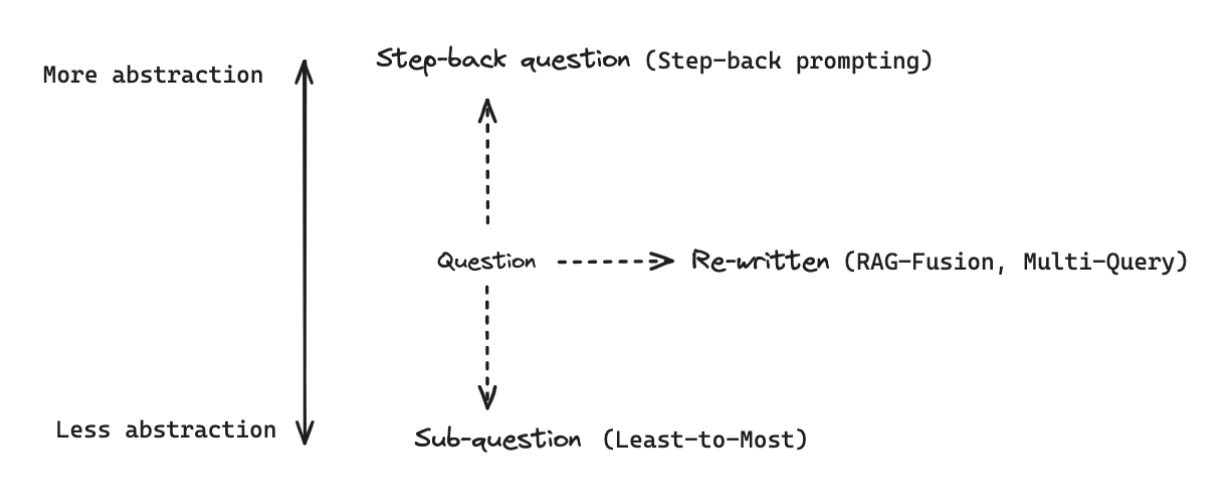

In [1]:
import bs4
import os
from langchain_community.document_loaders import WebBaseLoader
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from dotenv import load_dotenv
load_dotenv()
api_key = os.getenv("ADV_RAG_KEY")

loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
blog_docs = loader.load()
blog_docs

USER_AGENT environment variable not set, consider setting it to identify your requests.


[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='\n\n      LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistake

In [2]:
# Split
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=300, 
    chunk_overlap=50)

# Make splits
splits = text_splitter.split_documents(blog_docs)
splits, "", len(splits)

([Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and ref

In [3]:
vectorstore = Chroma.from_documents(documents=splits, 
                                    embedding=GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001"))

retriever = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={"k": 4, "fetch_k": 20, "lambda_mult": 0.5}
)
retriever 

VectorStoreRetriever(tags=['Chroma', 'GoogleGenerativeAIEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x000001F1E4A7FAD0>, search_type='mmr', search_kwargs={'k': 4, 'fetch_k': 20, 'lambda_mult': 0.5})

In [4]:
retriever.invoke("What is task decomposition for LLM agents?")

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Component One: Planning#\nA complicated task usually involves many steps. An agent needs to know what they are and plan ahead.\nTask Decomposition#\nChain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is instructed to “think step by step” to utilize more test-time computation to decompose hard tasks into smaller and simpler steps. CoT transforms big tasks into multiple manageable tasks and shed lights into an interpretation of the model’s thinking process.\nTree of Thoughts (Yao et al. 2023) extends CoT by exploring multiple reasoning possibilities at each step. It first decomposes the problem into multiple thought steps and generates multiple thoughts per step, creating a tree structure. The search process can be BFS (breadth-first search) or DFS (depth-first search) with each state evaluated by a

In [9]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import (
    RunnableLambda,
    RunnableParallel,
    RunnablePassthrough,
)
from langchain_google_genai import ChatGoogleGenerativeAI


llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0, api_key=api_key)
llm

ChatGoogleGenerativeAI(profile={'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-2.5-flash', temperature=0.0, client=<google.genai.client.Client object at 0x000001F1E967CD90>, default_metadata=(), model_kwargs={})

In [10]:
from langchain_core.prompts import FewShotChatMessagePromptTemplate

examples = [
    {
        "input": "Could the members of The Police perform lawful arrests?",
        "output": "What powers do members of The Police have?",
    },
    {
        "input": "Jan Sindel was born in what country?",
        "output": "What is known about Jan Sindel's background and life?",
    },
]

example_prompt = ChatPromptTemplate.from_messages(
    [
        ("human", "{input}"),
        ("ai", "{output}"),
    ]
)

few_shot_prompt = FewShotChatMessagePromptTemplate(
    example_prompt=example_prompt,
    examples=examples,
)

In [11]:
step_back_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
You are an expert at rewriting questions.

Given a specific question, generate a broader, more generic
question that is easier to answer and provides useful
background knowledge.

Only return the rewritten question.
""",
        ),
        few_shot_prompt,
        ("human", "{question}"),
    ]
)

In [ ]:
generate_step_back_question = (
    step_back_prompt
    | llm
    | StrOutputParser()
)
# This auto-guessing only works if the prompt is incredibly simple.

# In your case, your step_back_prompt is complex: it has a system message, a few_shot_prompt 
# (which is its own nested object with its own variables), and a human message. Because of that 
# few_shot_prompt sitting in the middle, LangChain's auto-guess feature breaks. It looks at the prompt and says, 
# "Whoa, there is too much going on here for me to guess. You have to give me a dictionary so 
# I know exactly what goes where."
# so we have to send it as a dict only here
generate_step_back_question.invoke({"question" : "What is task decomposition for LLM agents?"})

'How do LLM agents approach and solve complex problems?'

In [13]:
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

In [14]:
response_prompt = ChatPromptTemplate.from_template(
"""
You are an expert AI assistant.

Answer the user's question using both the directly
retrieved context and the broader step-back context.

If the step-back context is useful, incorporate it.
Otherwise focus on the normal context.

Normal Context:
{normal_context}

Step-Back Context:
{step_back_context}

Question:
{question}

Answer:
"""
)

chain = (
    {
        "normal_context":
            retriever
            | RunnableLambda(format_docs),

        "step_back_context":
            generate_step_back_question
            | retriever
            | RunnableLambda(format_docs),

        "question":
            RunnablePassthrough(),
    }
    | response_prompt
    | llm
    | StrOutputParser()
)

In [16]:
question = "What is task decomposition for LLM agents?"

response = chain.invoke(question)

response

'Task decomposition for LLM agents is the process of breaking down a complex task into smaller, simpler, and more manageable steps. This technique is crucial for enhancing the performance of language models (LLMs) on challenging tasks.\n\nHere\'s a breakdown of its aspects:\n\n*   **Purpose:** It allows LLMs to utilize more test-time computation, transforming large, difficult problems into a series of smaller, more tractable sub-tasks. It also provides insight into the model\'s thinking process.\n*   **Techniques:**\n    *   **Chain of Thought (CoT):** A standard prompting technique where the model is instructed to "think step by step" to decompose tasks.\n    *   **Tree of Thoughts (ToT):** An extension of CoT that explores multiple reasoning possibilities at each step, creating a tree structure of thoughts. This involves decomposing the problem into multiple thought steps and generating several thoughts per step, which can then be searched using strategies like Breadth-First Search (